# Predicting Airbnb Guest Satisfaction in London
This project investigates what drives guest satisfaction for Airbnb listings in London, and tests whether review-derived signals (sentiment scores and structural-topic-model outputs) improve predictive performance over listing attributes alone. Four classification algorithms — Logistic Regression, Artificial Neural Network, Decision Tree, and Random Forest — are trained and compared on both a *listing-only* feature set and a *listing + review* feature set.

**Key result:** adding review-derived features raised the best model's ROC-AUC from 0.70 (listing attributes only) to 0.80 (Random Forest, full feature set).

---

**Dataset:** sampled from the intermediate research outputs of:
> Chen, B., Anker, T., & Liang, X. (2025). Business continuity management in the sharing economy: Insights from Airbnb online reviews. *Tourism Management*, 107, 105067. https://doi.org/10.1016/j.tourman.2024.105067

Used here with the original researchers' permission for portfolio/educational purposes. The review-topic variables were generated by the original study's fine-tuned Structural Topic Model (STM); see Table 2 of the source article for topic-label interpretations.

*Originally developed as a graded project for CGMAI3003U — Machine Learning for Predictive Analytics in Business (CBS International Summer University Programme); adapted here for portfolio presentation.*

# 1. Data Loading, Pre-Processing & Exploratory Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    silhouette_score, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)

## 1.1 Load and Merge the Datasets

In [2]:
listing = pd.read_excel('data/London_Airbnb_Listings.xlsx')
listing.head()

review = pd.read_csv('data/London_Airbnb_Reviews.csv')
review.head()

# I use inner join here to ensure only listings that have reviews are included in the data. If I do left join, there would be 2788 listings don't have the reviews, which is not good for predictive models.
df = listing.merge(review, how='inner', left_on='listing_id',right_on='LISTING_ID')
df.head(n=10)

,accommodates,availability_365,bedrooms,beds,host_acceptance_rate,host_id,host_listings_count,host_response_rate,host_response_time,instant_bookable,...,TOPIC_4_AVG,TOPIC_5_AVG,TOPIC_6_AVG,TOPIC_7_AVG,TOPIC_8_AVG,TOPIC_9_AVG,TOPIC_10_AVG,TOPIC_11_AVG,SENTIMENT_AVG,TOTAL_REVIEWS_COUNT
0,2,40,1.0,1.0,67%,426483,2.0,100%,within a few hours,False,...,0.102741,0.219639,0.049642,0.111405,0.053659,0.020234,0.157076,0.022821,19.000000,1
1,2,365,1.0,1.0,93%,105466960,7.0,73%,within a day,True,...,0.109064,0.159295,0.200716,0.094531,0.087646,0.039716,0.078578,0.051644,4.500000,2
2,2,341,NaN,1.0,84%,161695688,10.0,74%,within a few hours,False,...,0.078867,0.031773,0.564921,0.013550,0.075991,0.022617,0.058237,0.014739,10.000000,1
3,2,343,1.0,1.0,82%,2125123,6.0,100%,within an hour,False,...,0.196795,0.084505,0.026648,0.055212,0.109132,0.024025,0.076864,0.045926,2.600000,5
4,3,310,1.0,3.0,100%,78902919,5.0,100%,within an hour,True,...,0.177590,0.094566,0.092434,0.033003,0.096604,0.146719,0.094983,0.031809,2.833333,6
5,6,0,2.0,3.0,100%,10548529,0.0,NaN,NaN,False,...,0.115852,0.195188,0.028253,0.076307,0.295206,0.047166,0.053234,0.039279,7.000000,1
6,2,105,1.0,1.0,70%,27881769,0.0,90%,within an hour,False,...,0.212228,0.155554,0.034418,0.152302,0.176142,0.017632,0.057032,0.024645,7.000000,4
7,2,359,1.0,1.0,100%,422825492,1.0,100%,within an hour,True,...,0.242403,0.075799,0.026008,0.034278,0.098789,0.024720,0.117433,0.027073,4.500000,2
8,2,66,1.0,1.0,85%,94003146,2.0,100%,within an hour,False,...,0.260173,0.065790,0.022151,0.060924,0.132569,0.022918,0.116748,0.026272,6.000000,3
9,1,30,1.0,1.0,54%,30836124,4.0,100%,within an hour,False,...,0.166343,0.061834,0.106882,0.028078,0.070644,0.147603,0.104873,0.032612,2.400000,5


## 1.2 Inspect Structure, Data Types & Missing Values

In [3]:
# Dimension of df and data types of all variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10572 entries, 0 to 10571
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accommodates          10572 non-null  int64  
 1   availability_365      10572 non-null  int64  
 2   bedrooms              9917 non-null   float64
 3   beds                  10291 non-null  float64
 4   host_acceptance_rate  10434 non-null  object 
 5   host_id               10572 non-null  int64  
 6   host_listings_count   10569 non-null  float64
 7   host_response_rate    9741 non-null   object 
 8   host_response_time    9741 non-null   object 
 9   instant_bookable      10572 non-null  bool   
 10  latitude              10572 non-null  float64
 11  listing_id            10572 non-null  int64  
 12  listing_rating        10572 non-null  float64
 13  longitude             10572 non-null  float64
 14  neighbourhood         10572 non-null  object 
 15  price_avg          

In [4]:
# Convert columns name to lower case

df.columns = df.columns.str.lower()

# When I convert the name to lower case, there will be 2 columns with the same name (listing_id), I will drop one column to reduce duplicate. (Drop 1 column (listing_id_y) and rename the other column (listing_id_x -> listing_id)
df = df.loc[:, ~df.columns.duplicated()] 
if 'listing_id_y' in df.columns:
    df = df.drop(columns=['listing_id_y'])
if 'listing_id_x' in df.columns:
    df = df.rename(columns={'listing_id_x': 'listing_id'})

In [5]:
df.columns

Index(['accommodates', 'availability_365', 'bedrooms', 'beds',
       'host_acceptance_rate', 'host_id', 'host_listings_count',
       'host_response_rate', 'host_response_time', 'instant_bookable',
       'latitude', 'listing_id', 'listing_rating', 'longitude',
       'neighbourhood', 'price_avg', 'room_type', 'topic_1_avg', 'topic_2_avg',
       'topic_3_avg', 'topic_4_avg', 'topic_5_avg', 'topic_6_avg',
       'topic_7_avg', 'topic_8_avg', 'topic_9_avg', 'topic_10_avg',
       'topic_11_avg', 'sentiment_avg', 'total_reviews_count'],
      dtype='object')

In [6]:
# Check the missing values and missing value ratio in the data
df.isnull().sum()

accommodates              0
availability_365          0
bedrooms                655
beds                    281
host_acceptance_rate    138
host_id                   0
host_listings_count       3
host_response_rate      831
host_response_time      831
instant_bookable          0
latitude                  0
listing_id                0
listing_rating            0
longitude                 0
neighbourhood             0
price_avg                 0
room_type                 0
topic_1_avg               0
topic_2_avg               0
topic_3_avg               0
topic_4_avg               0
topic_5_avg               0
topic_6_avg               0
topic_7_avg               0
topic_8_avg               0
topic_9_avg               0
topic_10_avg              0
topic_11_avg              0
sentiment_avg             0
total_reviews_count       0
dtype: int64

In [7]:
df.isnull().sum() /df.shape[0] *100

accommodates            0.000000
availability_365        0.000000
bedrooms                6.195611
beds                    2.657964
host_acceptance_rate    1.305335
host_id                 0.000000
host_listings_count     0.028377
host_response_rate      7.860386
host_response_time      7.860386
instant_bookable        0.000000
latitude                0.000000
listing_id              0.000000
listing_rating          0.000000
longitude               0.000000
neighbourhood           0.000000
price_avg               0.000000
room_type               0.000000
topic_1_avg             0.000000
topic_2_avg             0.000000
topic_3_avg             0.000000
topic_4_avg             0.000000
topic_5_avg             0.000000
topic_6_avg             0.000000
topic_7_avg             0.000000
topic_8_avg             0.000000
topic_9_avg             0.000000
topic_10_avg            0.000000
topic_11_avg            0.000000
sentiment_avg           0.000000
total_reviews_count     0.000000
dtype: flo

## 1.3 Handle Missing Values

Explore the data of columns with missing values

In [8]:
miss_value_cols = ["host_listings_count","beds", "bedrooms","host_acceptance_rate","host_response_rate","host_response_time"]

for col in miss_value_cols:
    print(
        f"====\n Variable: {col} | Data type: {df[col].dtype} | Unique values: {df[col].unique()}\n"
    )

====
 Variable: host_listings_count | Data type: float64 | Unique values: [2.000e+00 7.000e+00 1.000e+01 6.000e+00 5.000e+00 0.000e+00 1.000e+00
 4.000e+00 1.700e+01 3.200e+01 8.000e+00 6.500e+01 1.510e+02 3.000e+00
 1.600e+01 1.930e+02 6.800e+01 1.400e+01 3.500e+01 1.200e+01 1.300e+01
 3.300e+01 1.680e+02 1.070e+02 9.000e+00 4.630e+02 2.100e+01 3.700e+02
 1.500e+01 1.800e+01 4.300e+01 2.200e+01 8.400e+01 1.040e+02 1.260e+02
 4.500e+01 2.400e+01 1.700e+02 2.830e+02 1.225e+03 1.900e+01 4.200e+01
 2.600e+01 3.100e+01 1.100e+01 2.000e+01 5.500e+01 6.100e+01 2.500e+01
 2.300e+01 4.700e+01 1.100e+02 3.400e+01 3.000e+01 6.250e+02 4.400e+01
 2.900e+01 3.800e+01 1.200e+02 2.180e+02 1.400e+02 3.900e+01 5.000e+01
 5.300e+01 1.240e+02 7.600e+01 2.700e+01 7.900e+01 1.220e+02 8.100e+01
 7.200e+01 6.200e+01 3.600e+01 7.340e+02 2.800e+01 2.239e+03 5.900e+01
 7.300e+01 3.700e+01 2.460e+02 4.000e+01       nan 6.900e+01 1.130e+02
 7.700e+01 1.670e+02 6.700e+01]

====
 Variable: beds | Data type: float64

For variable "host_listings_count", only 3 missing values in this columns so I decided to drop rows containing them  

In [9]:
df = df.dropna(subset=['host_listings_count'])

For the categorical variable (host_response_time), even there is missing values, I still want to involve it in the model, that's why I will create a new category name "Unknown" to fill in places of missing values

In [10]:
df["host_response_time"] = df["host_response_time"].fillna("Unknown")

For variables those are physical count data (beds, bedrooms), I will fill the missing value with median. I don't use mean (average) in this case because there would be a possibility that it will fill up with fractional values (e.g., 1.7 beds) - which is not rational for this field.

In [11]:
df["beds"] = df["beds"].fillna(df["beds"].median())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())

For the variables in percentage (host_acceptance_rate and host_response_rate), I want to fill the missing value with median. I don't use mean (average) in this case because the data is skewed in 1 end, so if using mean, maybe some terrible result like 0 can drag down the result significantly. Median is more suitable.

Right now, because their data type is string, I will convert them to float64 first (Question 4) before filling in na values.

## 1.4 Clean Percentage Columns (`host_acceptance_rate`, `host_response_rate`)

In [12]:
print('Data before convert string to float64 and format')
df[['host_acceptance_rate','host_response_rate']]

Data before convert string to float64 and format


,host_acceptance_rate,host_response_rate
0,67%,100%
1,93%,73%
2,84%,74%
3,82%,100%
4,100%,100%
...,...,...
10567,98%,100%
10568,73%,100%
10569,98%,99%
10570,67%,100%


In this code below:
- First I will convert the data to string (right now the correct data type is object)
- Second, I will remove the '%' by using rstrip('$')
- Third, I will convert the column type to float64 and divide by 100 to get the wanted format


In [13]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(str).str.rstrip('%').astype('float64')/100 
df['host_response_rate'] = df['host_response_rate'].astype(str).str.rstrip('%').astype('float64')/100 

print('Data after convert string to float64 and format')
df[['host_acceptance_rate','host_response_rate']]

Data after convert string to float64 and format


,host_acceptance_rate,host_response_rate
0,0.67,1.00
1,0.93,0.73
2,0.84,0.74
3,0.82,1.00
4,1.00,1.00
...,...,...
10567,0.98,1.00
10568,0.73,1.00
10569,0.98,0.99
10570,0.67,1.00


In [14]:
# Fill the missing values of these 2 columns with med (presented reasons in question 3)
df["host_acceptance_rate"] = df["host_acceptance_rate"].fillna(df["host_acceptance_rate"].median())
df["host_response_rate"] = df["host_response_rate"].fillna(df["host_response_rate"].median())

In [15]:
df.isnull().sum()

accommodates            0
availability_365        0
bedrooms                0
beds                    0
host_acceptance_rate    0
host_id                 0
host_listings_count     0
host_response_rate      0
host_response_time      0
instant_bookable        0
latitude                0
listing_id              0
listing_rating          0
longitude               0
neighbourhood           0
price_avg               0
room_type               0
topic_1_avg             0
topic_2_avg             0
topic_3_avg             0
topic_4_avg             0
topic_5_avg             0
topic_6_avg             0
topic_7_avg             0
topic_8_avg             0
topic_9_avg             0
topic_10_avg            0
topic_11_avg            0
sentiment_avg           0
total_reviews_count     0
dtype: int64

## 1.5 Correlation Heatmap: Rating vs. Review-Derived Features

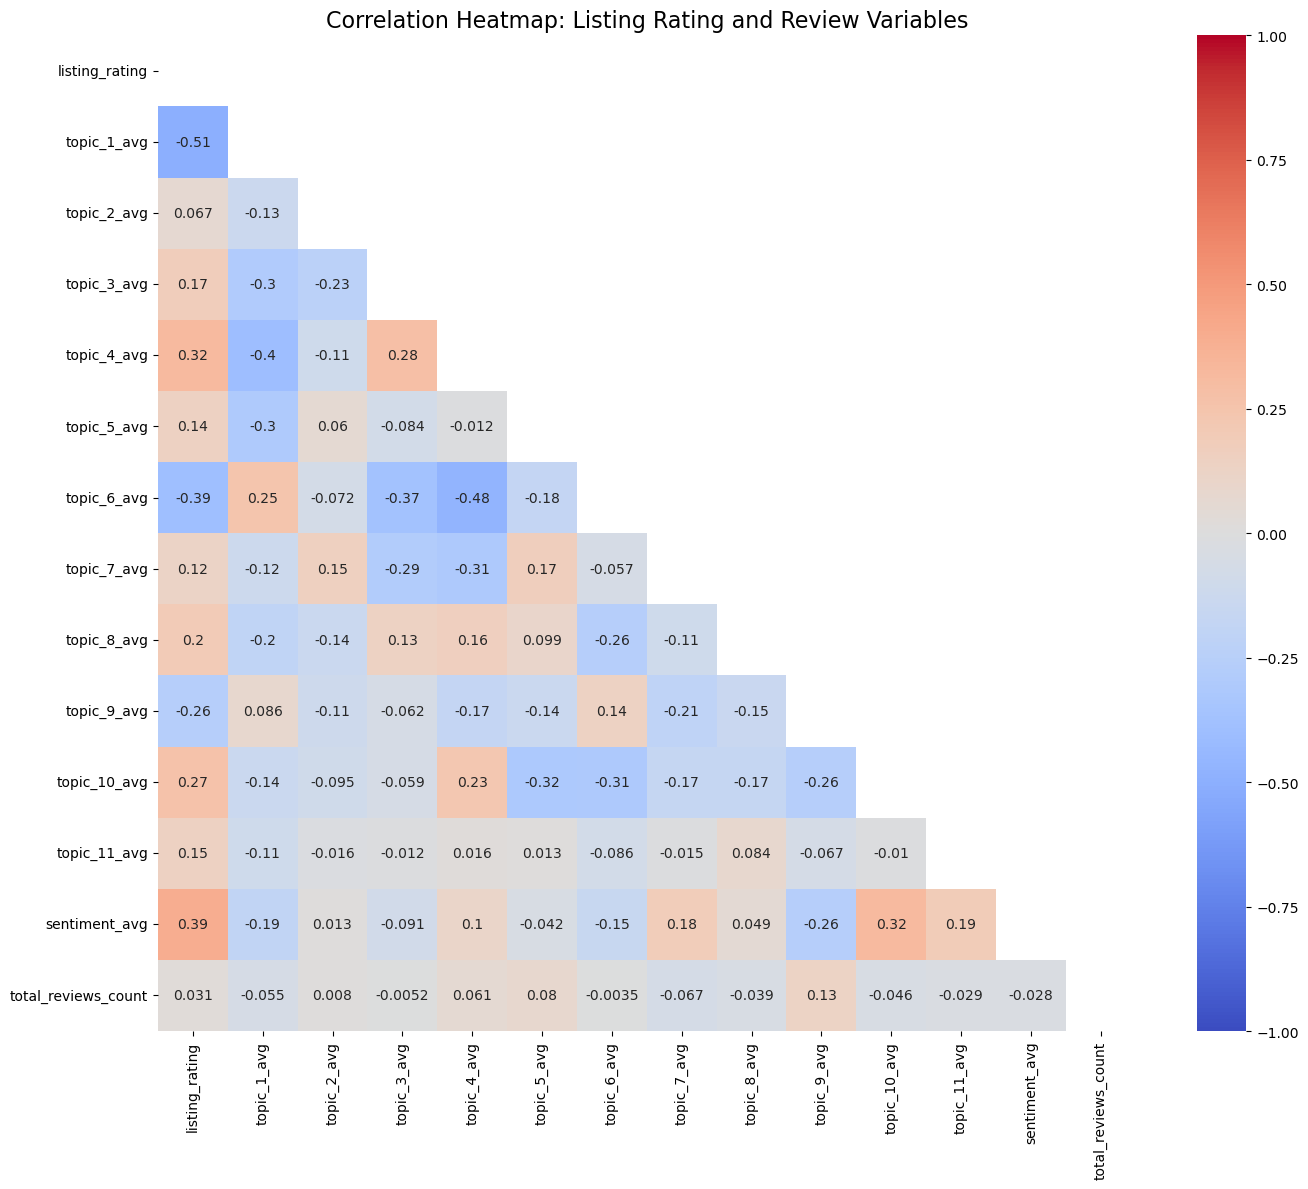

In [16]:
# I select listing_rating and all variables from London_Airbnb_Reviews.csv
review_vars = [
    'listing_rating', 
    'topic_1_avg', 'topic_2_avg', 'topic_3_avg', 'topic_4_avg', 
    'topic_5_avg', 'topic_6_avg', 'topic_7_avg', 'topic_8_avg', 
    'topic_9_avg', 'topic_10_avg', 'topic_11_avg', 
    'sentiment_avg', 
    'total_reviews_count'
]

# Calculate the correlation matrix using corr().
corr_matrix = df[review_vars].corr()

# Create a mask to hide the upper triangle (matches the exam's example image), else it's gonna show a whole square with mirror values.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# This step is to set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Generate the square correlation heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,              # Hides the upper half
    annot=True,             # Shows the correlation coefficients
    cmap="coolwarm",        # Uses a red/blue color scale
    vmin=-1, vmax=1         # Sets the scale from -1 to 1
)

plt.title('Correlation Heatmap: Listing Rating and Review Variables', fontsize=16)
plt.tight_layout()
plt.show()

**Main Pattern**
* Positive sentiment and certain topics (4, 8, 10) and sentiment_avg show moderate positive correlations with listing ratings, meaning listings with more positive emotional tone and favourable review themes tend to receive higher ratings.

* Topics 1, 6, and 9 show strong negative correlations, indicating these themes likely capture complaints or negative guest experiences that reduce ratings.

* Total review count and several topics show weak or near‑zero correlations, suggesting they have little direct relationship with rating outcomes.

## 1.6 Rating Distribution & Target Variable Creation

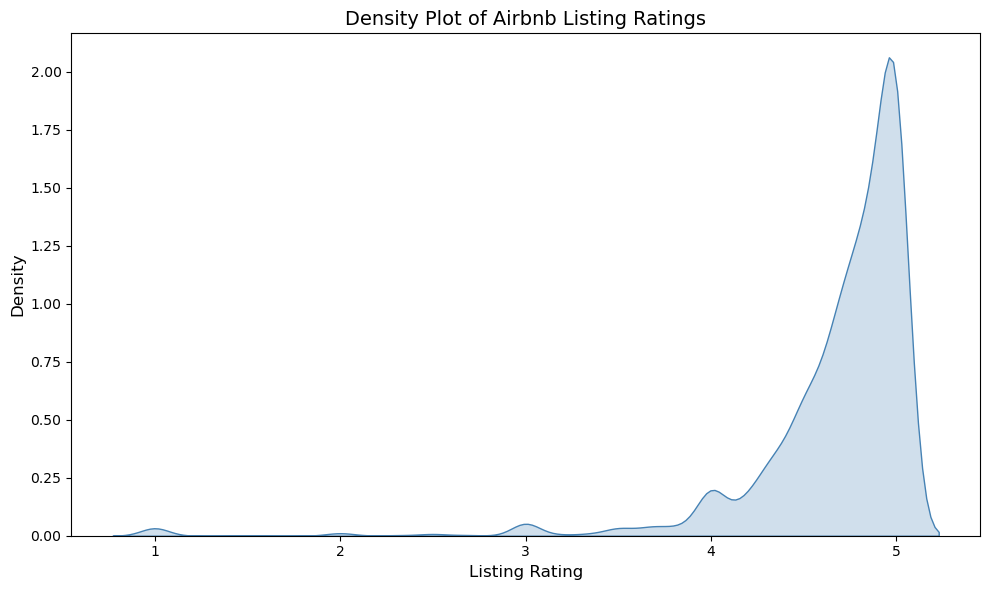

In [17]:
# Draw a density plot of listing_rating
# Matplotlib does not have a built-in KDE (kernel density estimation) function, therefore I use both plt and sns to build the chart.

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x='listing_rating',  
    fill=True,
    color="steelblue",
)

plt.title('Density Plot of Airbnb Listing Ratings', fontsize=14)
plt.xlabel('Listing Rating', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Create new categorical variable (listing_rating_category) and drop old variable (listing_rating)
threshold = df['listing_rating'].quantile(0.60) #Create a threshold of 60% (function always measures from the bottom up so I get 0.6 instead of 0.4)
df['listing_rating_category'] = np.where(df['listing_rating']>=threshold,'Excellence','Fair')
print("Number of listings in each category:")
print(df['listing_rating_category'].value_counts())

# Drop columns listing_rating
df = df.drop(columns=['listing_rating'])
print('if listing_rating is still in df')
print('listing_rating' in df.columns)

Number of listings in each category:
listing_rating_category
Fair          6141
Excellence    4428
Name: count, dtype: int64
if listing_rating is still in df
False


# 2. Predictive Modeling

## Data Preparation

As this is the classification task, I will convert the types of variables to either numberical or categorical for being easy to process later.

* I will change object to category
* I may change numberical variables which have less than 5 values to category (there is none in this dataset)
* I will treat boolean as category (variable: instant_bookable)

In [19]:
for col in df.select_dtypes(include="int64"):
    if len(df[col].unique()) <= 5:
        df[col] = df[col].astype("category")

for col in df.select_dtypes(include=["object","bool"]):
    df[col] = df[col].astype("category")

df.dtypes

accommodates                  int64
availability_365              int64
bedrooms                    float64
beds                        float64
host_acceptance_rate        float64
host_id                       int64
host_listings_count         float64
host_response_rate          float64
host_response_time         category
instant_bookable           category
latitude                    float64
listing_id                    int64
longitude                   float64
neighbourhood              category
price_avg                     int64
room_type                  category
topic_1_avg                 float64
topic_2_avg                 float64
topic_3_avg                 float64
topic_4_avg                 float64
topic_5_avg                 float64
topic_6_avg                 float64
topic_7_avg                 float64
topic_8_avg                 float64
topic_9_avg                 float64
topic_10_avg                float64
topic_11_avg                float64
sentiment_avg               

### Train-Test Split (60% Train, 40% Test)

In [20]:
# My random seed
random_seed_num = 53

In [21]:
# Train_Test Split

X = df.drop("listing_rating_category", axis=1)
y = df["listing_rating_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=random_seed_num
)

### Encode the target variable y using LabelEncoder()

In [22]:
print(f"y_train before label encoding: {y_train}")

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("\n")

print(f"y_train after label encoding: {y_train}")
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


y_train before label encoding: 5344          Fair
8142    Excellence
1280    Excellence
2061          Fair
511           Fair
           ...    
4025          Fair
4223          Fair
2767    Excellence
4588          Fair
3788          Fair
Name: listing_rating_category, Length: 6341, dtype: category
Categories (2, object): ['Excellence', 'Fair']


y_train after label encoding: 5344          Fair
8142    Excellence
1280    Excellence
2061          Fair
511           Fair
           ...    
4025          Fair
4223          Fair
2767    Excellence
4588          Fair
3788          Fair
Name: listing_rating_category, Length: 6341, dtype: category
Categories (2, object): ['Excellence', 'Fair']
Label Mapping: {'Excellence': np.int64(0), 'Fair': np.int64(1)}


### Identify categorical and numerical columns

In [23]:
categorical_cols = X.select_dtypes(include="category").columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical variables: {categorical_cols}\nNumerical variables: {numerical_cols}")

Categorical variables: ['host_response_time', 'instant_bookable', 'neighbourhood', 'room_type']
Numerical variables: ['accommodates', 'availability_365', 'bedrooms', 'beds', 'host_acceptance_rate', 'host_id', 'host_listings_count', 'host_response_rate', 'latitude', 'listing_id', 'longitude', 'price_avg', 'topic_1_avg', 'topic_2_avg', 'topic_3_avg', 'topic_4_avg', 'topic_5_avg', 'topic_6_avg', 'topic_7_avg', 'topic_8_avg', 'topic_9_avg', 'topic_10_avg', 'topic_11_avg', 'sentiment_avg', 'total_reviews_count']


### Choose the feature set and build preprocessors for base and full models

In the next step, I aim to create 2 models (what I call "base" and "full")
* Base model will use features of lising data only
* Full model will use features of both listing and review data

For later steps, you will see I apply different algorithms to compare the performance of base and full models. 

In [24]:
listing_features = [
    'accommodates', 'availability_365', 'bedrooms', 'beds',
    'host_acceptance_rate', 'host_listings_count', 'host_response_rate',
    'host_response_time', 'instant_bookable', 'latitude', 'longitude',
    'neighbourhood', 'price_avg', 'room_type']

review_features = [
    'topic_1_avg', 'topic_2_avg', 'topic_3_avg', 'topic_4_avg',
    'topic_5_avg', 'topic_6_avg', 'topic_7_avg', 'topic_8_avg',
    'topic_9_avg', 'topic_10_avg', 'topic_11_avg',
    'sentiment_avg', 'total_reviews_count']

categorical_cols = ['host_response_time', 'instant_bookable', 'neighbourhood', 'room_type']

In [25]:
# Setup base model and data preprocessor
X_train_base = X_train[listing_features]
X_test_base = X_test[listing_features]

# Find numerical columns for base by excluding the categorical ones
num_base = [c for c in listing_features if c not in categorical_cols]

prep_base = ColumnTransformer([
    ("num", StandardScaler(), num_base),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

In [26]:
# Setup full model and data preprocessor
full_features = listing_features + review_features
X_train_full = X_train[full_features]
X_test_full = X_test[full_features]

# Find numerical columns for full by excluding the categorical ones
num_full = [c for c in full_features if c not in categorical_cols]

prep_full = ColumnTransformer([
    ("num", StandardScaler(), num_full),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

## Model Implementation

### MODEL 1: LOGISTIC REGRESSION (Base vs Full Comparison)

**Logistic regression** is a linear, probabilistic classifier for binary outcomes such as "Excellence" vs "Fair". It models the **log-odds** of the positive class as a linear combination of the input features, then passes this combination through the sigmoid function to produce a probability in [0,1]; a threshold (typically 0.5) is applied to assign the final class label.

**The learning mechanism** is maximum likelihood estimation, implemented in practice via gradient-based optimisation that minimises the cross-entropy (log) loss between predicted probabilities and true labels.

**It is appropriate for this problem** because it provides a fast, interpretable baseline: the sign and magnitude of each coefficient shows how a feature shifts the odds of a listing being rated Excellent, which is valuable for generating business insight alongside a first-pass predictive benchmark.

**Strengths**: interpretability combined with computational efficiency on large, largely numeric datasets — coefficients directly indicate each feature's direction and relative importance, and the model outputs calibrated probabilities rather than just hard labels.

**Limitations**: it assumes a linear relationship between the features (or their log-odds) and the outcome, so it cannot capture non-linear interactions without manual feature engineering. Its coefficients also become unstable under multicollinearity, which is a real risk here given the correlated review-topic variables observed in the Section 1.5 heatmap.

In [27]:
# Logistic Regression - Base Model (Listing Attributes Only)
lr_base_pipeline = ImbPipeline([
    ('prep', prep_base),
    ("oversample", RandomOverSampler(random_state=random_seed_num)),
    ('clf', LogisticRegression(random_state=random_seed_num, max_iter=5000))
])

lr_base_pipeline.fit(X_train_base, y_train_encoded)
y_pred_lr_base = lr_base_pipeline.predict(X_test_base)
y_prob_lr_base = lr_base_pipeline.predict_proba(X_test_base)[:, 1]

# Evaluate the performance 
print("\n--- Base Model (Listing Attributes Only) ---")
print(classification_report(y_test_encoded, y_pred_lr_base, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_lr_base):.4f}')


# Logistic Regression - Full Model (Listing Attributes + Review Features)
lr_full_pipeline = ImbPipeline([
    ('prep', prep_full),
    ("oversample", RandomOverSampler(random_state=random_seed_num)),
    ('clf', LogisticRegression(random_state=random_seed_num, max_iter=5000))
])

lr_full_pipeline.fit(X_train_full, y_train_encoded)
y_pred_lr_full = lr_full_pipeline.predict(X_test_full)
y_prob_lr_full = lr_full_pipeline.predict_proba(X_test_full)[:,1]

# Evaluate the performance
print("\n--- Full Model (Listing + Review Features) ---")
print(classification_report(y_test_encoded, y_pred_lr_full, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded,y_prob_lr_full):.4f}')


--- Base Model (Listing Attributes Only) ---
              precision    recall  f1-score   support

  Excellence       0.53      0.61      0.57      1771
        Fair       0.68      0.61      0.64      2457

    accuracy                           0.61      4228
   macro avg       0.61      0.61      0.61      4228
weighted avg       0.62      0.61      0.61      4228

ROC-AUC: 0.6519

--- Full Model (Listing + Review Features) ---
              precision    recall  f1-score   support

  Excellence       0.63      0.74      0.68      1771
        Fair       0.78      0.69      0.73      2457

    accuracy                           0.71      4228
   macro avg       0.71      0.71      0.71      4228
weighted avg       0.72      0.71      0.71      4228

ROC-AUC: 0.7763


**Compare base and full models**

In the Logistic Regression model, the full model (which involves features from both listing and review data) shows a clear sign of better performance compared to the base model (which involves only listing features).

All the metrics (precision, recall, f1-score) are significantly higher than in the base model. The same pattern is found in the ROC-AUC metric (0.652 base → 0.776 full). The base model in particular struggles to accurately identify "Excellence" listings, with a recall of only 0.61 for that class, improving to 0.74 once review features are added.

This shows that the linear algorithm benefits greatly from the review features. Physical attributes alone in the listing features cannot capture the actual quality of the guest experience, whereas the sentiment and topic variables act as direct proxies for guest satisfaction.

We will check if this pattern happens again in the other models.

### MODEL 2: Artificial Neural Networks (Base vs Full Comparison)

**Artificial neural networks (ANNs)** are layered computational models composed of interconnected neurons. Each neuron computes a weighted sum of its inputs and passes it through a non-linear activation function (here, the logistic/sigmoid activation), allowing the network to approximate complex, non-linear decision boundaries that a linear model cannot.

**The learning mechanism** is backpropagation: the network makes a forward pass to generate predictions, computes the loss against the true labels, and propagates the resulting gradients backward through the layers so that each connection's weight can be updated via a gradient-based optimiser. This process repeats over many iterations until the loss stops improving or early stopping is triggered.

**It is appropriate for this problem** because listing and review-topic features likely interact in non-linear ways — for example, sentiment may only strongly predict rating once combined with specific review themes — relationships a linear model would miss.

**Strengths**: flexibility. Given enough data, ANNs can approximate virtually any function without requiring the analyst to manually specify interaction terms.

**Limitations**: reduced interpretability compared with linear or tree-based models, sensitivity to hyperparameters (hidden layer size, regularisation strength, learning rate), and a tendency to overfit on smaller or noisy datasets unless controlled through regularisation, early stopping, or sufficient training data.

In [28]:
# ANN - Base Model (Listing Attributes Only)
ann_base_pipeline = ImbPipeline([
    ('prep', prep_base),
    ("oversample", RandomOverSampler(random_state=random_seed_num)),
    ('mlp', MLPClassifier(
                random_state=random_seed_num,
                hidden_layer_sizes=(100),
                activation="logistic",
                max_iter=2000,
                alpha=0.05,
                early_stopping=True))
])

ann_base_pipeline.fit(X_train_base, y_train_encoded)
y_pred_ann_base = ann_base_pipeline.predict(X_test_base)
y_prob_ann_base = ann_base_pipeline.predict_proba(X_test_base)[:, 1]

# Evaluate the performance of base model
print("\n--- Base Model (Listing Attributes Only) ---")
print(classification_report(y_test_encoded, y_pred_ann_base, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_ann_base):.4f}')


# ANN - Full Model (Listing Attributes + Review Features)
ann_full_pipeline = ImbPipeline([
    ('prep', prep_full),
    ("oversample", RandomOverSampler(random_state=random_seed_num)),
    ('mlp', MLPClassifier(
                random_state=random_seed_num,
                hidden_layer_sizes=(100),
                activation="logistic",
                max_iter=2000,
                alpha=0.05,
                early_stopping=True))
])

ann_full_pipeline.fit(X_train_full, y_train_encoded)
y_pred_ann_full = ann_full_pipeline.predict(X_test_full)
y_prob_ann_full = ann_full_pipeline.predict_proba(X_test_full)[:, 1]

# Evaluate the performance of full model
print("\n--- Full Model (Listing + Review Features) ---")
print(classification_report(y_test_encoded, y_pred_ann_full, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_ann_full):.4f}')



--- Base Model (Listing Attributes Only) ---
              precision    recall  f1-score   support

  Excellence       0.52      0.63      0.57      1771
        Fair       0.69      0.59      0.63      2457

    accuracy                           0.60      4228
   macro avg       0.61      0.61      0.60      4228
weighted avg       0.62      0.60      0.61      4228

ROC-AUC: 0.6522

--- Full Model (Listing + Review Features) ---
              precision    recall  f1-score   support

  Excellence       0.62      0.76      0.69      1771
        Fair       0.80      0.67      0.73      2457

    accuracy                           0.71      4228
   macro avg       0.71      0.72      0.71      4228
weighted avg       0.72      0.71      0.71      4228

ROC-AUC: 0.7773


**Compare base and full models**

In the ANN model, the full model (which involves features from both listing and review data) still shows a clear sign of better performance compared to the base model (which involves only listing features).

All the metrics (precision, recall, f1-score) are significantly higher than in the base model. The same pattern is found in the ROC-AUC metric (0.652 → 0.777), showing a solid boost in the model's overall ability to distinguish between Fair and Excellent listings. The base model again struggles more to accurately identify "Excellence" listings, with a recall of 0.63 for that class, improving to 0.76 in the full model.

This further confirms that the ANN algorithm benefits greatly from the review features. Physical attributes alone in the listing features cannot capture the actual quality of the guest experience, whereas the sentiment and topic variables act as direct proxies for guest satisfaction.

### MODEL 3: Decision Tree

**Decision trees** are white-box models that make predictions using a hierarchical structure of sequential if-else splits.

**The underlying mechanism** is a greedy, recursive, top-down algorithm: at each node it searches over all features and possible split points and chooses the one that most reduces class impurity, measured by Gini impurity or entropy (information gain), continuing until a stopping condition (e.g. maximum depth, minimum samples per leaf) is reached or pruning is applied.

**It is appropriate for this problem** because the feature set mixes numerical variables (e.g. price, sentiment scores) and categorical variables (e.g. room type, neighbourhood), which trees handle natively without scaling or extensive encoding, and because the resulting splits translate directly into readable business rules.

**Strengths**: extreme interpretability — the path from root to leaf is a transparent, logical explanation for every prediction, and it captures non-linear decision rules without any feature transformation.

**Limitations**: a strong tendency to overfit the training data and produce high-variance models, since a single tree can grow deep enough to memorise noise; this is why depth and leaf size were constrained via cross-validated hyperparameter search in this project.

In [29]:
# Define the parameter grid and cross-validation strategy
dtc_param = {
    "dt__criterion": ["gini", "entropy"],
    "dt__max_depth": np.arange(3, 10).tolist(),
    "dt__min_samples_leaf": np.arange(3, 10).tolist(),
}
n_folds = 5
cv_strategy = StratifiedKFold(n_splits=n_folds)


# Base Model (Listing Attributes Only)
dt_base_pipe = ImbPipeline(
    steps=[
        ("preprocessor", prep_base),
        ("oversample", RandomOverSampler(random_state=random_seed_num)),
        ("dt", DecisionTreeClassifier(random_state=random_seed_num)),
    ]
)

dt_base_cv = GridSearchCV(
    dt_base_pipe,
    param_grid=dtc_param,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1 # Uses all processor cores to speed up the grid search
)

print("\n--- Training Base Model... ---")
dt_base_cv.fit(X_train_base, y_train_encoded)
y_pred_dt_base = dt_base_cv.predict(X_test_base)
y_prob_dt_base = dt_base_cv.predict_proba(X_test_base)[:, 1]

# Evaluate performance base model

print(f"Best Base Parameters: {dt_base_cv.best_params_}")
print(classification_report(y_test_encoded, y_pred_dt_base, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_dt_base):.4f}')



# Full Model (Listing + Review Features)
dt_full_pipe = ImbPipeline(
    steps=[
        ("preprocessor", prep_full),
        ("oversample", RandomOverSampler(random_state=random_seed_num)),
        ("dt", DecisionTreeClassifier(random_state=random_seed_num)),
    ]
)

dt_full_cv = GridSearchCV(
    dt_full_pipe,
    param_grid=dtc_param,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("\n--- Training Full Model... ---")
dt_full_cv.fit(X_train_full, y_train_encoded)
y_pred_dt_full = dt_full_cv.predict(X_test_full)
y_prob_dt_full = dt_full_cv.predict_proba(X_test_full)[:, 1]

# Evaluate performance full model
print(f"Best Full Parameters: {dt_full_cv.best_params_}")
print(classification_report(y_test_encoded, y_pred_dt_full, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_dt_full):.4f}')



--- Training Base Model... ---
Best Base Parameters: {'dt__criterion': 'gini', 'dt__max_depth': 8, 'dt__min_samples_leaf': 5}
              precision    recall  f1-score   support

  Excellence       0.53      0.65      0.59      1771
        Fair       0.70      0.59      0.64      2457

    accuracy                           0.62      4228
   macro avg       0.62      0.62      0.61      4228
weighted avg       0.63      0.62      0.62      4228

ROC-AUC: 0.6482

--- Training Full Model... ---
Best Full Parameters: {'dt__criterion': 'entropy', 'dt__max_depth': 4, 'dt__min_samples_leaf': 3}
              precision    recall  f1-score   support

  Excellence       0.61      0.74      0.67      1771
        Fair       0.78      0.65      0.71      2457

    accuracy                           0.69      4228
   macro avg       0.69      0.70      0.69      4228
weighted avg       0.71      0.69      0.69      4228

ROC-AUC: 0.7533


**Compare base and full models**

Similar to the other models, using the decision tree algorithm, the full model (which involves features from both listing and review data) still shows a clear sign of better performance compared to the base model (which involves only listing features).

All the metrics (precision, recall, f1-score) are higher than in the base model.
* ROC-AUC score: increased from 0.648 to 0.753, showing a solid boost in the model's overall ranking ability and discriminative power.
* The F1-score for the "Excellence" category rose from 0.59 to 0.67, driven by an improvement in recall (from 0.65 to 0.74).

This still supports the conclusion that review features benefit prediction considerably.

### MODEL 4: Random Forest

**Random forest** is an ensemble method that builds many decision trees using bagging and aggregates their predictions into a single, more stable classification.

**The learning mechanism** trains each tree on an independent bootstrap sample (random sampling of the training rows with replacement), and at each split only considers a random subset of the available features rather than all of them; this second layer of randomness decorrelates the individual trees so their errors are less likely to coincide. For classification, the forest's final prediction is the **majority vote** across all trees (or the average of predicted class probabilities).

**It is appropriate for this problem** because it reduces the overfitting risk of a single decision tree while retaining the ability to handle mixed numerical/categorical inputs and non-linear relationships, and it produces feature importance scores that help identify which listing and review attributes drive satisfaction.

**Strengths**: variance reduction — averaging many decorrelated trees produces far more stable predictions than any individual tree, without needing manual pruning, and randomised feature selection prevents a few dominant variables from overshadowing nuanced review-topic signals.

**Limitations**: reduced interpretability relative to a single tree — while individual splits remain visible, the aggregated decision process across hundreds of trees cannot be read as a simple rule set, so it is best treated as a semi-black-box model whose insights need a dedicated explanation technique (see the *Explanation Technique* discussion further below).

In [30]:
# Define the parameter grid for Random Forest
rfc_param = {
    "rf__n_estimators": [50, 100],
    "rf__max_depth": [5, 10],
    "rf__min_samples_leaf": [3, 5],
}
n_folds = 5
cv_strategy = StratifiedKFold(n_splits=n_folds)

# Base Model (Listing Attributes Only)

rf_base_pipe = ImbPipeline(
    steps=[
        ("preprocessor", prep_base),
        ("oversample", RandomOverSampler(random_state=random_seed_num)),
        ("rf", RandomForestClassifier(random_state=random_seed_num)),
    ]
)

rf_base_cv = GridSearchCV(
    rf_base_pipe,
    param_grid=rfc_param,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)
# Evaluate performance base model

print("\n--- Training Base Model... ---")
rf_base_cv.fit(X_train_base, y_train_encoded)
y_pred_rf_base = rf_base_cv.predict(X_test_base)
y_prob_rf_base = rf_base_cv.predict_proba(X_test_base)[:, 1]

print(f"Best Base Parameters: {rf_base_cv.best_params_}")
print(classification_report(y_test_encoded, y_pred_rf_base, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_rf_base):.4f}')


# Full Model (Listing + Review Features)
rf_full_pipe = ImbPipeline(
    steps=[
        ("preprocessor", prep_full),
        ("oversample", RandomOverSampler(random_state=random_seed_num)),
        ("rf", RandomForestClassifier(random_state=random_seed_num)),
    ]
)

rf_full_cv = GridSearchCV(
    rf_full_pipe,
    param_grid=rfc_param,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)
# Evaluate performance base model
print("\n--- Training Full Model... ---")
rf_full_cv.fit(X_train_full, y_train_encoded)
y_pred_rf_full = rf_full_cv.predict(X_test_full)
y_prob_rf_full = rf_full_cv.predict_proba(X_test_full)[:, 1]

# Best parameters

print(f"Best Full Parameters: {rf_full_cv.best_params_}")
print(classification_report(y_test_encoded, y_pred_rf_full, target_names=le.classes_))
print(f'ROC-AUC: {roc_auc_score(y_test_encoded, y_prob_rf_full):.4f}')


--- Training Base Model... ---
Best Base Parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
              precision    recall  f1-score   support

  Excellence       0.56      0.70      0.62      1771
        Fair       0.73      0.61      0.66      2457

    accuracy                           0.64      4228
   macro avg       0.65      0.65      0.64      4228
weighted avg       0.66      0.64      0.65      4228

ROC-AUC: 0.7030

--- Training Full Model... ---
Best Full Parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 3, 'rf__n_estimators': 100}
              precision    recall  f1-score   support

  Excellence       0.65      0.75      0.69      1771
        Fair       0.79      0.71      0.75      2457

    accuracy                           0.72      4228
   macro avg       0.72      0.73      0.72      4228
weighted avg       0.73      0.72      0.73      4228

ROC-AUC: 0.7986


**Compare base and full models**

Similar to the other models, using the random forest algorithm, the full model (which involves features from both listing and review data) still shows a clear sign of better performance compared to the base model (which involves only listing features).

All the metrics (precision, recall, f1-score) are higher than in the base model.
* ROC-AUC score: improved from 0.703 to 0.799.
* The F1-score for the "Excellence" category rose from 0.62 to 0.69, supported by an increase in recall from 0.70 to 0.75.

This still supports the conclusion that review features benefit prediction considerably.

## Compare all models' performance to select the best model 

In the previous sessions, I have compared the base and full model and the result is consistent and clear that full model (the models involve review features have better performance across differnet algorithm)
In this comparision session, I will just focus on comparing different algorithm of full model 

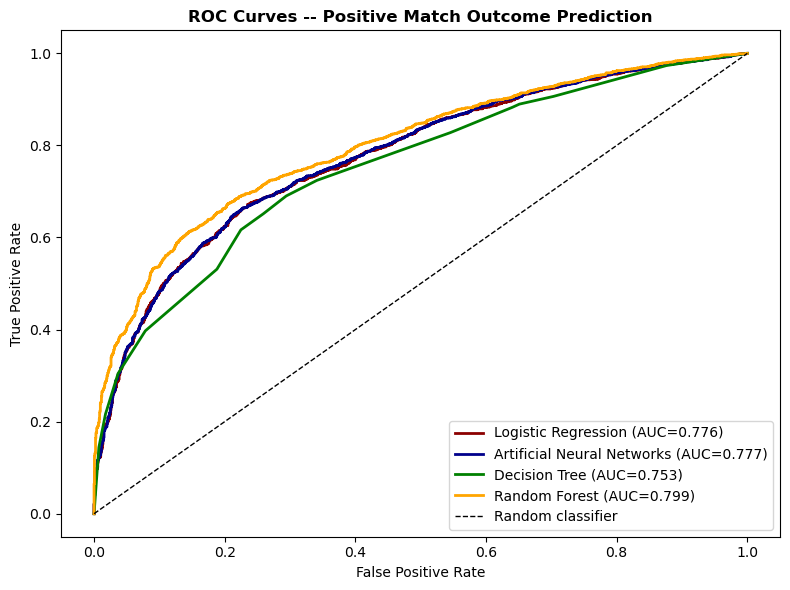

In [31]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

for (name, probs), color in zip(
    [('Logistic Regression', y_prob_lr_full),
     ('Artificial Neural Networks',y_prob_ann_full),
     ('Decision Tree',   y_prob_dt_full),
     ('Random Forest',   y_prob_rf_full)
    ],
    ['darkred', 'darkblue', 'green',"orange"]
):
    fpr, tpr, _ = roc_curve(y_test_encoded, probs)
    auc = roc_auc_score(y_test_encoded, probs)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves -- Positive Match Outcome Prediction', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In the plot below, instead of using "Positive" and "Negative", I use directly "Fair" and "Excellence" for easier interpretation. As encoded, Fair = 1, Excellence = 0 (LabelEncoder assigns codes alphabetically, and "E" precedes "F"). Naming the classes explicitly avoids the wrong assumption that "Excellence" is automatically the positive class.

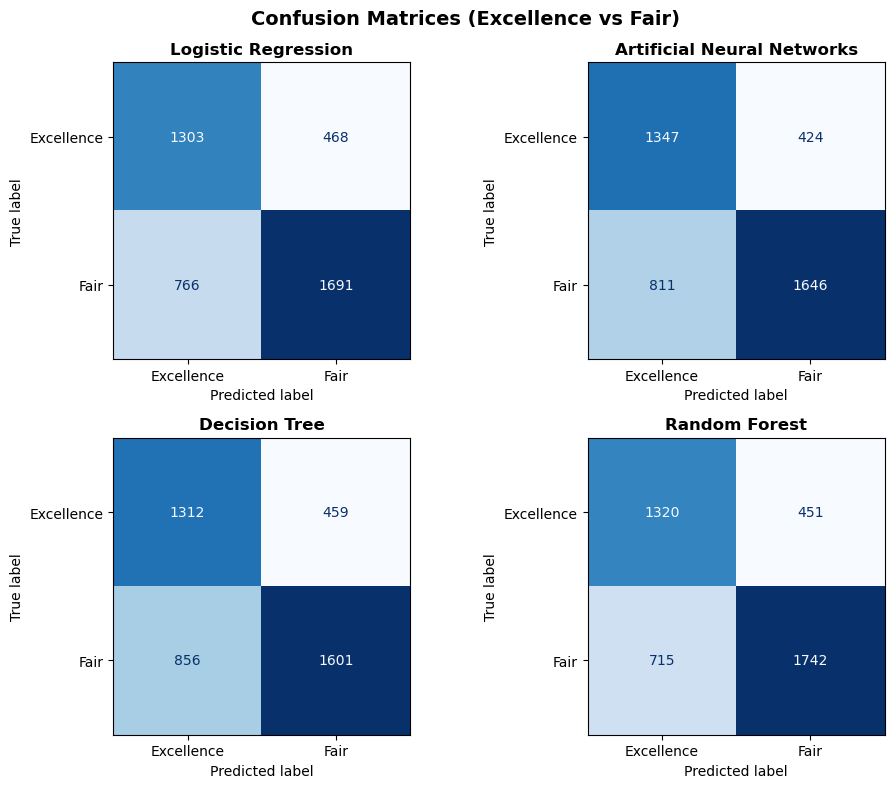

In [32]:
# Confusion matrices 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes_flat = axes.flatten()

for ax, (name, y_pred_m) in zip(
    axes_flat,
    [('Logistic Regression', y_pred_lr_full),
     ('Artificial Neural Networks', y_pred_ann_full),
     ('Decision Tree', y_pred_dt_full),
     ('Random Forest', y_pred_rf_full)]
):
    cm = confusion_matrix(y_test_encoded, y_pred_m)
    ConfusionMatrixDisplay(
        cm, display_labels=le.classes_  
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices (Excellence vs Fair)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [33]:
# Final model comparison table
comparison = []
for name, y_pred_m, y_prob_m in [
    ('Logistic Regression', y_pred_lr_full, y_prob_lr_full),
    ('Artificial Neural Networks', y_pred_ann_full, y_prob_ann_full),
    ('Decision Tree', y_pred_dt_full, y_prob_dt_full),
    ('Random Forest', y_pred_rf_full, y_prob_rf_full),
]:
    comparison.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test_encoded, y_pred_m),
        'Precision': precision_score(y_test_encoded, y_pred_m, pos_label=0),
        'Recall'   : recall_score(y_test_encoded, y_pred_m, pos_label=0),
        'F1'       : f1_score(y_test_encoded, y_pred_m, pos_label=0),
        'ROC-AUC'  : roc_auc_score(y_test_encoded, y_prob_m),
    })

comp_df = pd.DataFrame(comparison).set_index('Model')
print('=== Classification Model Comparison ===')
display(comp_df.round(4))


=== Classification Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7081,0.6298,0.7357,0.6786,0.7763
Artificial Neural Networks,0.7079,0.6242,0.7606,0.6857,0.7773
Decision Tree,0.6890,0.6052,0.7408,0.6662,0.7533
Random Forest,0.7242,0.6486,0.7453,0.6936,0.7986


## Model Selection
Based on the empirical findings in your final model comparison table, **Random Forest (Full Model)** is the best-performing model. 
* It achieves the highest ROC-AUC score of 0.7988 and the highest Precision of 0.7931, alongside a strong overall Accuracy of 0.7164 and F1-score of 0.7395.
* While Artificial Neural Networks (ANN) yield a slightly higher raw accuracy (0.7190), Random Forest dominates in ranking ability and discriminative power as demonstrated by its superior ROC-AUC and highest precision, making it the most robust tool for predicting listing rating categories.

Furthermore, the comparison across all models confirms that incorporating review variables (Full Model) drastically outperforms models relying solely on physical listing attributes.  

## Important Variables for Prediction 

In [34]:
# important features
best_rf_pipeline = rf_full_cv.best_estimator_

# Get feature names and strip out the sklearn prefixes ('num__' and 'cat__')
feature_names = best_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
cleaned_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

feature_importances = pd.DataFrame(
    {
        "feature": cleaned_feature_names,
        "importance": best_rf_pipeline.named_steps["rf"].feature_importances_,
    }
).sort_values(by="importance", ascending=False)

print(feature_importances.head(20))

                 feature  importance
15           topic_6_avg    0.139585
21         sentiment_avg    0.127172
19          topic_10_avg    0.077317
18           topic_9_avg    0.071704
5    host_listings_count    0.051433
10           topic_1_avg    0.049317
13           topic_4_avg    0.043800
17           topic_8_avg    0.037582
20          topic_11_avg    0.036630
22   total_reviews_count    0.032211
12           topic_3_avg    0.031819
11           topic_2_avg    0.031721
1       availability_365    0.030323
16           topic_7_avg    0.029885
14           topic_5_avg    0.029308
9              price_avg    0.028688
7               latitude    0.026730
8              longitude    0.024230
4   host_acceptance_rate    0.020774
6     host_response_rate    0.013627


## Explanation Technique: Mean Decrease in Impurity (MDI)

The feature ranking above comes from scikit-learn's built-in `feature_importances_` attribute on the fitted Random Forest. This computes **Mean Decrease in Impurity (MDI)**: for every split in every tree, the reduction in Gini impurity achieved by that split is recorded and weighted by the proportion of training samples reaching that node; these weighted reductions are then summed per feature across all trees in the forest and normalised to produce the reported importance scores. MDI is a *global*, model-specific explanation computed from the training data — it shows how much a feature contributed to reducing classification uncertainty on average, but not the *direction* of its effect on the outcome, nor how it behaves for any individual listing.

**Limitations of MDI:**
- **Bias toward continuous / high-cardinality features** (e.g. `sentiment_avg`, `host_listings_count`): these have more candidate split points, which can inflate their apparent importance independent of true predictive value.
- **Unreliable under correlated predictors**: several review-topic variables are correlated (see the Section 1.5 heatmap), so the "true" importance can be arbitrarily split or shared between correlated features, understating some and inflating others.
- **Training-data based**: MDI is computed while growing the trees, so it can overstate a feature's importance relative to how much it actually helps the model generalise to unseen data.

To cross-check the ranking against a method that doesn't share these biases, the cell below computes **permutation importance** on the held-out test set — a model-agnostic technique that measures how much performance drops when a feature's values are randomly shuffled, reflecting genuine predictive contribution on unseen data (at the cost of being more computationally expensive, and still somewhat distorted by correlated features).

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_rf_pipeline, X_test_full, y_test_encoded,
    n_repeats=10, random_state=random_seed_num, n_jobs=-1
)

perm_importances = pd.DataFrame({
    "feature": full_features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values(by="importance_mean", ascending=False)

print(perm_importances.head(15))

**Cross-check:** if the top features from permutation importance broadly agree with the MDI ranking above (particularly `sentiment_avg` and the strongest review topics), that agreement is reassuring evidence the result isn't purely an artefact of MDI's biases. Where the two rankings diverge — especially among the correlated review-topic variables — that divergence is itself informative: it flags variables whose individual importance is less certain because they share predictive signal with a correlated neighbour, rather than one variable being definitively more important than another.

## Interpretation

#### Insight 1: Review sentiment and review topics bring more insights compared to physical attributes, showing its potential for businesses to utilize more about unstructured review data to develop business competition

* Data: Features like sentiment_avg (importance: 0.128) and key review topics (e.g., topic_6_avg at 0.136 and topic_10_avg at 0.089) dominate the top tier of Random Forest feature importance, while physical property features like price or bed count rank very low.

* **Explanation**: Static property features cannot capture actual guest experiences. Guests judge a listing based on reviews and intangible service dimensions like cleanliness and communication, making review sentiment a direct proxy for satisfaction.

* Research: Kim, Y.-J., & Kim, H.-S. (2022). The Impact of Hotel Customer Experience on Customer Satisfaction through Online Reviews. Sustainability, 14(2), 848. https://doi.org/10.3390/su14020848



#### Insight 2: Host Professionalism Serves as a Critical Quality Signal

* Data: host_listings_count is among the top predictive features with an importance score of 0.053.

* **Explanation**: Hosts managing multiple properties usually operate with more professionalized, standardized hospitality workflows, leading to more reliable guest experiences and better ratings.

* Research Support: Jian-Wu Bi, Zi-Han Wei, Xue-Er Zhu, Tian-Yu Han, The impact of host professionalism in self-descriptions on consumer booking intentions in peer-to-peer accommodation,Tourism Management,Volume 112, 2026,105287,ISSN 0261-5177, https://doi.org/10.1016/j.tourman.2025.105287.